#Mini Project: EvaluatingClustering Before and After PCA

##1. Preprocess data

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_wine

In [ ]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
X = wine.data
y = wine.target

In [ ]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##2. Apply Clustering (Before PCA)

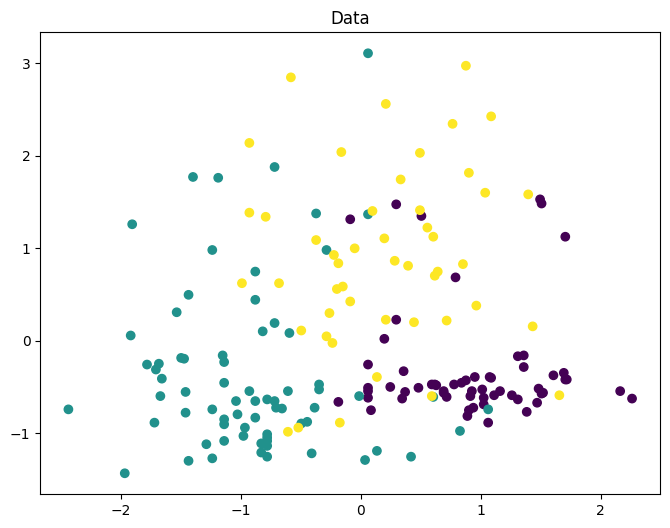

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap="viridis")
plt.title("Data")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
inertia = []

for k in range(1,10):
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

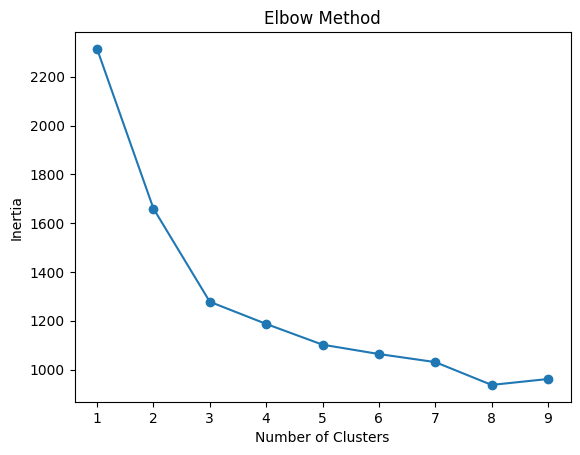

In [ ]:
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
print("Silhouette:", silhouette_score(X_scaled, clusters))

Silhouette: 0.2806817957373884


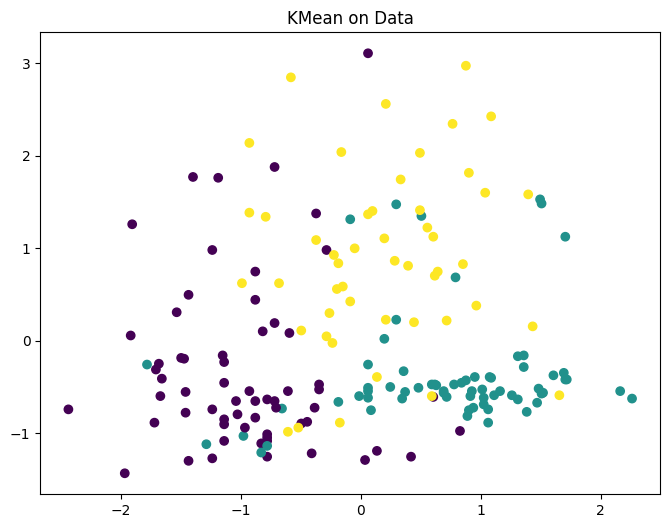

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="viridis")
plt.title("KMean on Data")
plt.show()

##3. Apply PCA

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(178, 3)


In [ ]:
print(pca.explained_variance_ratio_)

[0.36198848 0.1920749  0.11123631]


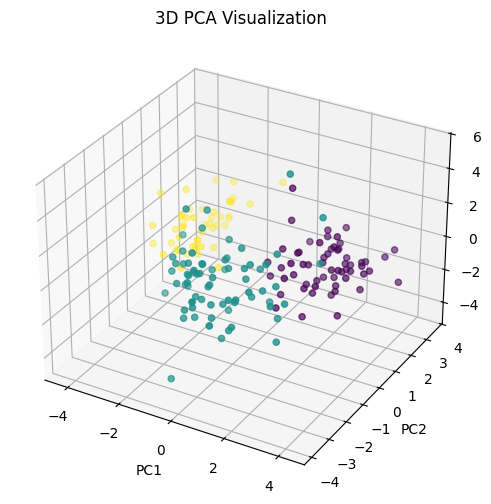

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2],c=y, cmap='viridis')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Visualization")
plt.show()

##4. Apply Clustering (After PCA)

In [ ]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_pca)

In [ ]:
print("Silhouette:", silhouette_score(X_pca, clusters))

Silhouette: 0.45231070192832795


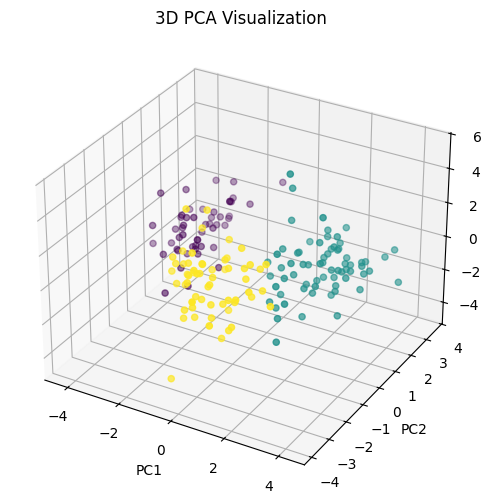

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter( X_pca[:,0], X_pca[:,1],X_pca[:,2],c=clusters,cmap='viridis')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Visualization")
plt.show()

##5. Visualization

##6.Analysis

In [ ]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.36198848 0.1920749  0.11123631]
0.6652996889318523


###How did PCA affect clustering results?
####-PCA reduced the dimensionality of the dataset while preserving most of the important variance. This helped remove redundant information and noise, making the clustering algorithms more efficient.

###Did visualization become clearer? yes

###Did you lose important information?
####-some information was lost after applying PCA. The first three principal components retained 66.53% of the total variance, meaning approximately 33.47% of the original variance was discarded.

###Which approach is better and why?
####- After PCA the Silhouette Score is higher, And the clearer

| Metric             | Before PCA | After PCA |
| ------------------ | ----------: | -------: |
| Silhouette Score   |    **0.28** |     **0.45** |
| Explained Variance |        100% |   66.53% |
| Visualization      |  Less clear |  Clearer |


| PCA Components | Explained Variance (%) | Silhouette Score | Visualization | Recommendation            |
| -------------: | ---------------------: | ---------------: | ------------- | ------------------------- |
|              2 |                  55 |             0.56 | Very clear    | Good for visualization    |
|              3 |                  66.53 |             0.40 | Clear         | Good balance              |
|              4 |                  73.60 |             0.40 | Clear         | Best overall              |
|              5 |                  80.16 |             0.36 | Less clear    | More information retained |


## Bonus

In [ ]:
db = DBSCAN( eps=3,min_samples=3)
clusters_db = db.fit_predict(X_scaled)

In [ ]:
score = silhouette_score( X_scaled, clusters_db )
print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.19109689467931046


In [ ]:
mask = clusters_db != -1
score = silhouette_score(X_scaled[mask], clusters_db[mask])
print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.2391871796270332


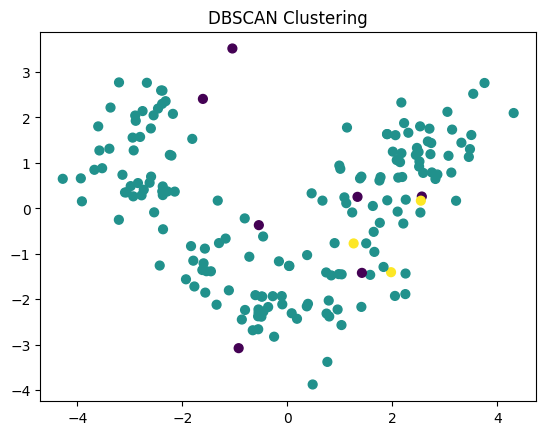

In [ ]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters_db,cmap="viridis",s=40)
plt.title("DBSCAN Clustering")
plt.show()

| Metric                             |             K-Means |                                        DBSCAN |
| ---------------------------------- | ------------------: | --------------------------------------------: |
| Silhouette Score                   |            **0.45** |                                      **0.23** |
| Cluster Separation                 |              Better |                                      Moderate |
| Handles Outliers                   |                No |                                          Yes |
| Cluster Shape                      |    Spherical/Convex |                              Arbitrary Shapes |
| Need to Specify Number of Clusters |                Yes |                                          No |
| Best Use Case                      | Well-separated data | Data with noise and irregular-shaped clusters |
